# Tabulated Resolution Kernels

Previous notebooks used an analytical Gaussian resolution model (`flight_path_m`,
`delta_t_us`, `delta_l_m`). Real instrument resolution is **asymmetric** — the
moderator pulse produces a sharp leading edge and an exponential tail that a
symmetric Gaussian cannot capture.

This notebook demonstrates the tabulated resolution API:

| Function | Purpose |
|----------|---------|
| `load_resolution(path, flight_path_m)` | Load kernels from a Monte Carlo file |
| `forward_model(..., resolution=tab)` | Transmission with tabulated resolution |
| `spatial_map_typed(..., resolution=tab)` | Fitting with tabulated resolution in the inner loop |
| `apply_resolution(energies, spectrum, resolution)` | Standalone broadening |

## Resolution File Format

NEREIDS reads a text file whose structure is:

```text
<header line>
-----
   E_ref_1 (eV)   0.0
   tof_offset_1 (μs)   weight_1
   tof_offset_2        weight_2
   ...                              ← N points per kernel
                                    ← blank line separates blocks
   E_ref_2 (eV)   0.0
   ...
```

Each kernel $R(\Delta t; E_\text{ref})$ gives the normalised instrument response as a
function of TOF offset $\Delta t$ (μs) at a reference energy $E_\text{ref}$.
Kernels are peak-normalised (max weight = 1.0).

> **Note on the resolution file used here**: The file `examples/data/venus_resolution_synthetic.txt`
> is a **synthetic mock** generated with a Gaussian + exponential-tail model (L = 25 m,
> FWHM ≈ 350 ns). It has the same format as a real VENUS/FTS file and produces
> qualitatively similar asymmetric kernels, but its parameters do not correspond to
> the actual beamline optics. The real instrument resolution file is available from
> the VENUS instrument scientists.

## Prerequisites

```bash
pixi run build
```

In [ ]:
import nereids
import numpy as np
import matplotlib.pyplot as plt
import os
import pathlib

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

np.random.seed(42)

# Resolve the path relative to the repo root, regardless of where Jupyter was
# launched.  Jupyter launched from the notebook directory, the repo root, or
# anywhere else in the tree will all find the same file via this walk-up.
def _repo_root() -> pathlib.Path:
    """Walk up from CWD until Cargo.toml (the repo root marker) is found."""
    for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (p / 'Cargo.toml').exists():
            return p
    raise RuntimeError("Cannot locate repo root: Cargo.toml not found above CWD")

RES_PATH = str(_repo_root() / 'examples' / 'data' / 'venus_resolution_synthetic.txt')
assert os.path.exists(RES_PATH), f"Synthetic resolution file not found: {RES_PATH}"


def fit_spectrum_1d(T_1d, sigma_1d, energies, isotopes, **kwargs):
    """Convenience wrapper: fit a single 1D spectrum via the typed API."""
    T_3d = np.ascontiguousarray(T_1d[:, None, None])
    sigma_3d = np.ascontiguousarray(sigma_1d[:, None, None])
    data = nereids.from_transmission(T_3d, sigma_3d)
    result = nereids.spatial_map_typed(data, energies, isotopes, **kwargs)

    class _Result:
        pass

    r = _Result()
    r.densities = [m[0, 0] for m in result.density_maps]
    r.uncertainties = [m[0, 0] for m in result.uncertainty_maps]
    r.reduced_chi_squared = float(np.array(result.chi_squared_map)[0, 0])
    r.converged = bool(np.array(result.converged_map)[0, 0])
    return r

## 1. Loading a Resolution File

`load_resolution(path, flight_path_m)` parses the tabulated kernel file and
returns a `TabulatedResolution` object.  The flight path converts TOF offsets
(μs) to energy offsets (eV) inside the broadening integrals.

In [2]:
tab = nereids.load_resolution(RES_PATH, flight_path_m=25.0)
print(tab)
print(f"  Reference energies: {tab.n_energies}")
print(f"  Energy range:       {tab.energy_range[0]:.4e} to {tab.energy_range[1]:.4e} eV")
print(f"  Points per kernel:  {tab.points_per_kernel}")
print(f"  Flight path:        {tab.flight_path_m} m")

TabulatedResolution(n_energies=25, range=[5.0000e-4, 1.0000e3] eV, flight_path=25.0 m)
  Reference energies: 25
  Energy range:       5.0000e-04 to 1.0000e+03 eV
  Points per kernel:  258
  Flight path:        25.0 m


## 2. Kernel Shape at Different Energies

The kernel $R(\Delta t; E_\text{ref})$ changes shape with energy.  At low energies
the kernel is **broad** (long TOF, large $\Delta t / t$); at high energies it is
**narrow**.  Real instrument kernels are **asymmetric** — a sharp leading edge from
the prompt moderator pulse followed by an exponential tail.

Parsed 25 reference kernels


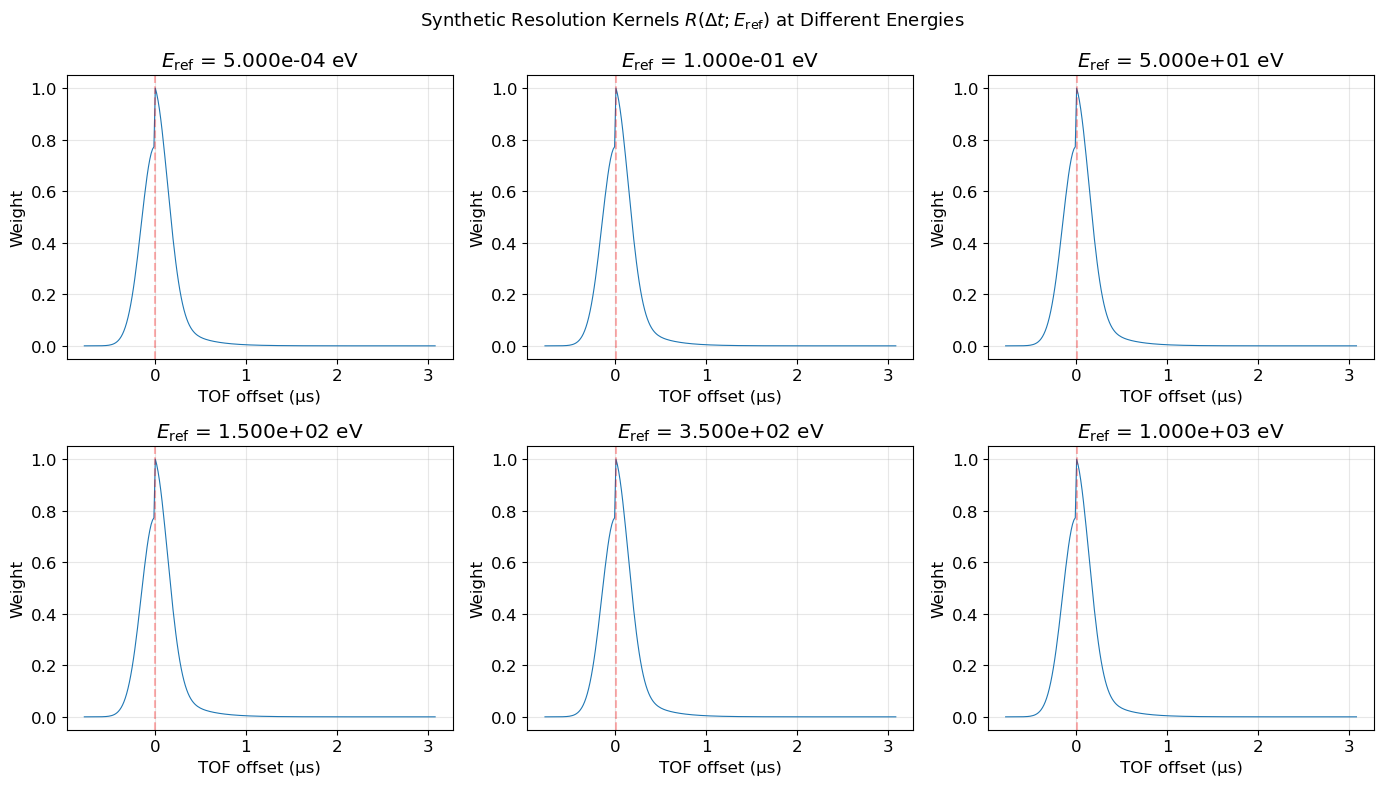

Note: kernels widen at low energy (long TOF) and sharpen at high energy


In [3]:
# Parse the kernel blocks directly from the file for visualisation
with open(RES_PATH) as f:
    text = f.read()
lines = text.strip().split('\n')

blocks = []
current_e = None
offsets, weights = [], []
for line in lines[2:]:          # skip header + separator
    stripped = line.strip()
    if not stripped:
        if current_e is not None:
            blocks.append((current_e, np.array(offsets), np.array(weights)))
            current_e = None
            offsets, weights = [], []
        continue
    parts = stripped.split()
    if len(parts) != 2:
        continue
    x, y = float(parts[0]), float(parts[1])
    if current_e is None:
        current_e = x
    else:
        offsets.append(x)
        weights.append(y)
if current_e is not None:
    blocks.append((current_e, np.array(offsets), np.array(weights)))

print(f"Parsed {len(blocks)} reference kernels")

# Plot six kernels across the energy range
n = len(blocks)
indices = [0, n//5, 2*n//5, 3*n//5, 4*n//5, n-1]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, idx in zip(axes.flat, indices):
    e, off, w = blocks[idx]
    ax.plot(off, w, linewidth=0.8)
    ax.set_title(f'$E_{{\\rm ref}}$ = {e:.3e} eV')
    ax.set_xlabel('TOF offset (μs)')
    ax.set_ylabel('Weight')
    ax.grid(True, alpha=0.3)
    peak_idx = np.argmax(w)
    ax.axvline(off[peak_idx], color='r', alpha=0.3, linestyle='--', label='peak')

fig.suptitle('Synthetic Resolution Kernels $R(\\Delta t; E_\\text{ref})$ at Different Energies',
             fontsize=13)
plt.tight_layout()
plt.show()

print("Note: kernels widen at low energy (long TOF) and sharpen at high energy")

## 3. Gaussian vs Tabulated Resolution

The analytical Gaussian approximation is symmetric; the tabulated kernel is
asymmetric.  This difference biases the fitted areal density when the data was
actually acquired with the asymmetric instrument response.

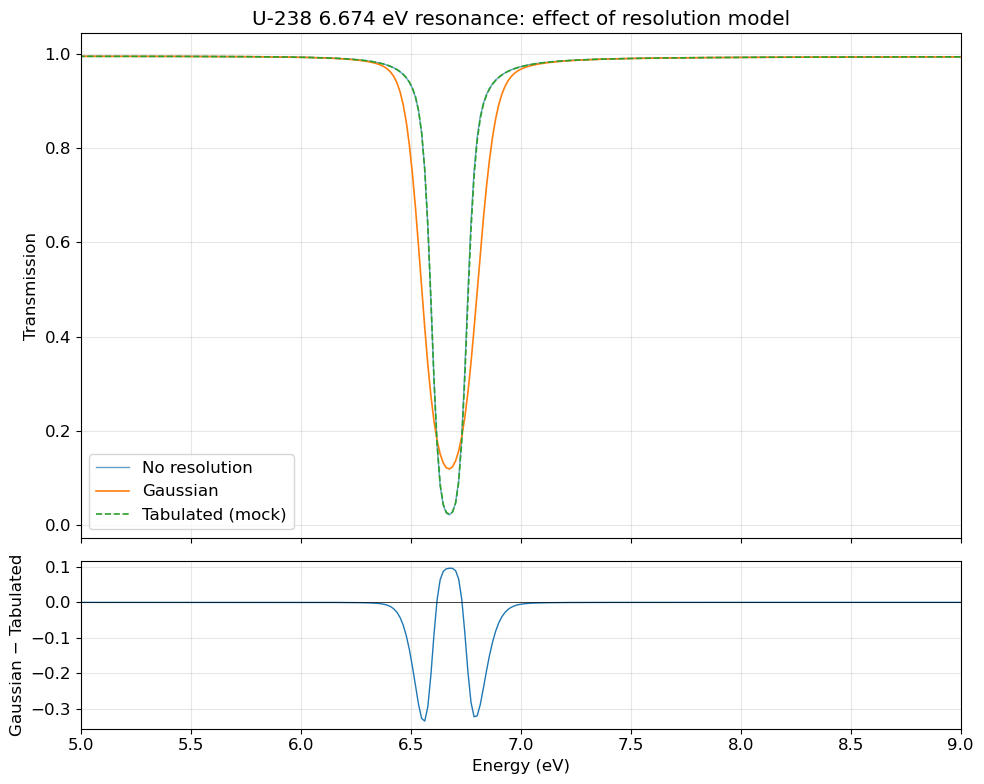

Max |Gaussian − Tabulated|: 0.3353


In [4]:
u238 = nereids.create_resonance_data(
    z=92, a=238, awr=236.006, scattering_radius=9.4285,
    resonances=[(6.674, 0.5, 1.493e-3, 23.0e-3)]
)

energies = np.linspace(1.0, 15.0, 1000)
density = 0.0005

T_none  = nereids.forward_model(energies, [(u238, density)], temperature_k=300.0)
T_gauss = nereids.forward_model(energies, [(u238, density)], temperature_k=300.0,
                                 flight_path_m=25.0, delta_t_us=5.0, delta_l_m=0.01)
T_tab   = nereids.forward_model(energies, [(u238, density)], temperature_k=300.0,
                                 resolution=tab)

fig, axes = plt.subplots(2, 1, figsize=(10, 8),
                          gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

axes[0].plot(energies, T_none,  label='No resolution',     linewidth=1.0, alpha=0.7)
axes[0].plot(energies, T_gauss, label='Gaussian',          linewidth=1.2)
axes[0].plot(energies, T_tab,   label='Tabulated (mock)',  linewidth=1.2, linestyle='--')
axes[0].set_ylabel('Transmission')
axes[0].set_title('U-238 6.674 eV resonance: effect of resolution model')
axes[0].legend()
axes[0].set_xlim(5, 9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(energies, np.asarray(T_gauss) - np.asarray(T_tab), linewidth=1.0)
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_xlabel('Energy (eV)')
axes[1].set_ylabel('Gaussian − Tabulated')
axes[1].set_xlim(5, 9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Max |Gaussian − Tabulated|: {np.max(np.abs(np.asarray(T_gauss) - np.asarray(T_tab))):.4f}")

## 4. Fitting with Tabulated Resolution

When the data was generated with the tabulated kernel, only a fit that uses the
**same** kernel recovers the true density without bias.  The Gaussian approximation
shows severe systematic error and elevated $\chi^2$ because its symmetric profile
does not match the asymmetric moderator pulse shape.

The no-resolution fit happens to give a low error (~1.3 %) and acceptable $\chi^2$
in this synthetic test case, because the mock kernel used here is relatively
narrow.  This is coincidental: with a real VENUS kernel — which is markedly
asymmetric and broader — the no-resolution fit would accumulate a systematic
density bias comparable to the Gaussian case.

In [ ]:
true_density = 0.0005
noise_level  = 0.01

T_true_tab = np.asarray(nereids.forward_model(
    energies, [(u238, true_density)], temperature_k=300.0, resolution=tab
))
T_measured = T_true_tab + np.random.normal(0, noise_level, len(energies))
sigma = np.full_like(T_measured, noise_level)

r_tab   = fit_spectrum_1d(T_measured, sigma, energies, [u238],
                           temperature_k=300.0, resolution=tab)
r_gauss = fit_spectrum_1d(T_measured, sigma, energies, [u238],
                           temperature_k=300.0,
                           flight_path_m=25.0, delta_t_us=5.0, delta_l_m=0.01)
r_none  = fit_spectrum_1d(T_measured, sigma, energies, [u238],
                           temperature_k=300.0)

print(f"True density: {true_density:.6f} atoms/barn\n")
hdr = f"{'Model':>22}  {'Density':>12}  {'Error':>8}  {'chi2_red':>8}"
print(hdr)
print('-' * len(hdr))
for name, r in [('Tabulated (correct)', r_tab),
                ('Gaussian (approx)',   r_gauss),
                ('No resolution',       r_none)]:
    err = abs(r.densities[0] - true_density) / true_density * 100
    print(f"{name:>22}  {r.densities[0]:>12.6f}  {err:>7.1f}%  {r.reduced_chi_squared:>8.3f}")

## 5. Standalone `apply_resolution()`

`apply_resolution()` applies tabulated broadening to any 1D spectrum (cross-section,
transmission, or arbitrary data) outside the forward model.  Useful for
post-processing or visual comparison.

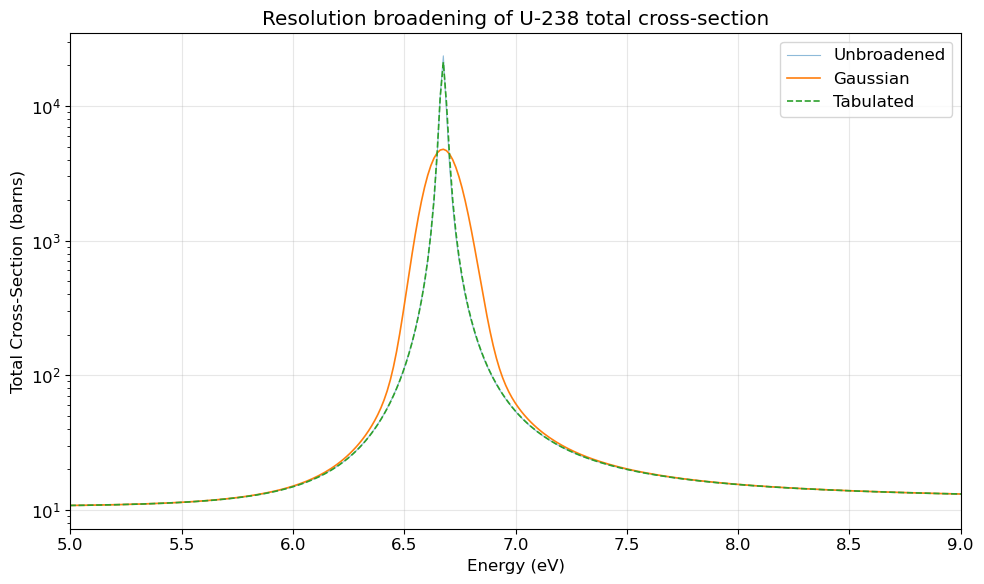

Peak unbroadened: 23585 barns
Peak Gaussian:    4771 barns
Peak Tabulated:   21165 barns


In [6]:
xs = nereids.cross_sections(energies, u238)
xs_total     = np.asarray(xs['total'])
xs_broadened = nereids.apply_resolution(energies, xs_total, tab)
xs_gauss     = nereids.resolution_broaden(energies, xs_total, 25.0, 5.0, 0.01)

fig, ax = plt.subplots()
ax.semilogy(energies, xs_total,     label='Unbroadened', linewidth=0.8, alpha=0.5)
ax.semilogy(energies, xs_gauss,     label='Gaussian',    linewidth=1.2)
ax.semilogy(energies, xs_broadened, label='Tabulated',   linewidth=1.2, linestyle='--')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Total Cross-Section (barns)')
ax.set_title('Resolution broadening of U-238 total cross-section')
ax.legend()
ax.set_xlim(5, 9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Peak unbroadened: {np.max(xs_total):.0f} barns")
print(f"Peak Gaussian:    {np.max(np.asarray(xs_gauss)):.0f} barns")
print(f"Peak Tabulated:   {np.max(np.asarray(xs_broadened)):.0f} barns")

## Summary

| Function | Purpose |
|----------|---------|
| `load_resolution(path, L)` | Parse Monte Carlo kernel file into `TabulatedResolution` |
| `forward_model(..., resolution=tab)` | Transmission convolved with tabulated kernel |
| `spatial_map_typed(..., resolution=tab)` | Fitting with tabulated kernel in inner loop |
| `apply_resolution(E, spectrum, tab)` | Standalone broadening of any 1D spectrum |

Key takeaways:
- Real VENUS kernels $R(\Delta t; E_\text{ref})$ are **asymmetric** (moderator pulse shape) —
  a Gaussian approximation introduces systematic density bias.
- The tabulated resolution file for VENUS is available from the instrument scientists.
  The synthetic mock used here has the same format but does not reproduce the real
  beamline parameters.
- For custom instruments, generate a file in the same format from your Monte Carlo
  simulation (McStas, VITESS, etc.).

### 1D fitting with tabulated resolution

```python
data = nereids.from_transmission(T[:, None, None].copy(), sigma[:, None, None].copy())
result = nereids.spatial_map_typed(data, energies, [isotope], resolution=tab)
density = result.density_maps[0][0, 0]
```

**Previous**: [03_spectrum_fitting.ipynb](03_spectrum_fitting.ipynb) — where Gaussian
resolution is introduced.  Tabulated resolution is the natural extension for VENUS.

**Next**: [06_tiff_io_normalization.ipynb](06_tiff_io_normalization.ipynb) — loading
raw TIFF stacks and normalizing to transmission.